# Análisis Cruzado: Stablecoins, Cripto y Sistema de Alertas

Este notebook cruza los datos preprocesados de stablecoins y criptomonedas con el sistema de alertas
(`alertas_sistema_final.csv` y `alertas_criticas_informe.csv`) para responder:

1. ¿Qué variables de stablecoin distinguen a cada nivel de alerta?
2. ¿Cómo se comporta el mercado cripto grande (BTC/ETH/XRP/SOL) en cada nivel de alerta?
3. ¿Coinciden en el tiempo las crisis de peg con movimientos fuertes de BTC?
4. ¿Qué stablecoins concentran más alertas?

> Ajusta las rutas de la celda de carga si tu estructura de carpetas es distinta.

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.lines import Line2D

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Carga de datos

Se buscan los CSV en `../data/clean/` y `../data/alerts/` (misma convención que tus notebooks anteriores). Si no los encuentra ahí, prueba en la carpeta actual.

In [25]:

df_stable = pd.read_csv("../data/clean/datos_preprocesados_clean.csv")
df_crypto = pd.read_csv("../data/clean/criptoradar_crypto_final_clean.csv")
df_alertas = pd.read_csv("../data/clean/alertas_sistema_final.csv")
df_criticas = pd.read_csv("../data/clean/alertas_criticas_informe.csv")

for df in (df_stable, df_crypto, df_alertas, df_criticas):
    df["datetime"] = pd.to_datetime(df["datetime"])

df_alertas.shape, df_alertas["nivel_alerta"].value_counts()

((7182, 14),
 nivel_alerta
 0_normal                   7076
 1_VIGILANCIA_STABLECOIN      92
 2_ALERTA_MERCADO             14
 Name: count, dtype: int64)

## 2. Preparación: retornos diarios de cripto y unión con alertas

Calculamos el retorno diario (%) de cada criptomoneda grande a partir de su precio de cierre, y lo unimos
(por fecha) a **todas** las filas de `alertas_sistema_final.csv` — no solo a las críticas — para poder
comparar los 3 niveles de alerta entre sí, no solo ver el nivel 2 de forma aislada.

In [26]:
df_crypto_pivot = df_crypto.pivot(index="datetime", columns="crypto_id", values="close").sort_index()
df_returns = df_crypto_pivot.pct_change().rename(columns=lambda c: f"{c}_return")

df_merged = df_alertas.merge(df_returns, left_on="datetime", right_index=True, how="left")

ORDER = ["0_normal", "1_VIGILANCIA_STABLECOIN", "2_ALERTA_MERCADO"]
df_merged["nivel_alerta"] = pd.Categorical(df_merged["nivel_alerta"], categories=ORDER, ordered=True)

df_merged.head()

,datetime,price,market_cap,peg_deviation,supply_change_1d,supply_change_7d,price_volatility_3d,stablecoin,stablecoin_id,anomaly_score,is_anomaly_stablecoin,market_volatility,market_stress,nivel_alerta,bitcoin_return,ethereum_return,ripple_return,solana_return
0,2024-04-27,1.0,70416273.0,0.0,-0.003343,-0.003343,0.0,BUSD,4,0.252270,False,0.026167,False,0_normal,0.009253,0.055976,0.008374,0.031068
1,2024-04-28,1.0,70457805.0,0.0,0.000590,-0.000075,0.0,BUSD,4,0.259129,False,0.025955,False,0_normal,-0.007976,-0.041704,-0.015282,-0.038856
2,2024-04-29,1.0,70350839.0,0.0,-0.001518,-0.006253,0.0,BUSD,4,0.252929,False,0.047598,False,0_normal,-0.035602,-0.059184,-0.031663,-0.063945
3,2024-04-30,1.0,70510688.0,0.0,0.002272,-0.004986,0.0,BUSD,4,0.252523,False,0.035189,False,0_normal,-0.064251,-0.036243,0.005947,-0.034313
4,2024-05-01,1.0,70355422.0,0.0,-0.002202,-0.006188,0.0,BUSD,4,0.254262,False,0.061847,True,0_normal,0.041799,0.036396,0.042024,0.127168


## 3. Bloque 1 — Nivel de alerta vs. variables propias de la stablecoin

Categórica (`nivel_alerta`) vs. numéricas (`peg_deviation`, `price_volatility_3d`, `anomaly_score`, `market_volatility`).
`peg_deviation` y `price_volatility_3d` van en escala log porque su distribución está muy concentrada cerca de cero
con colas largas.

/var/folders/pq/7bx4chp93qg2ck6vkzg024800000gn/T/ipykernel_16197/4101735999.py:7: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale("log")
/var/folders/pq/7bx4chp93qg2ck6vkzg024800000gn/T/ipykernel_16197/4101735999.py:7: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale("log")


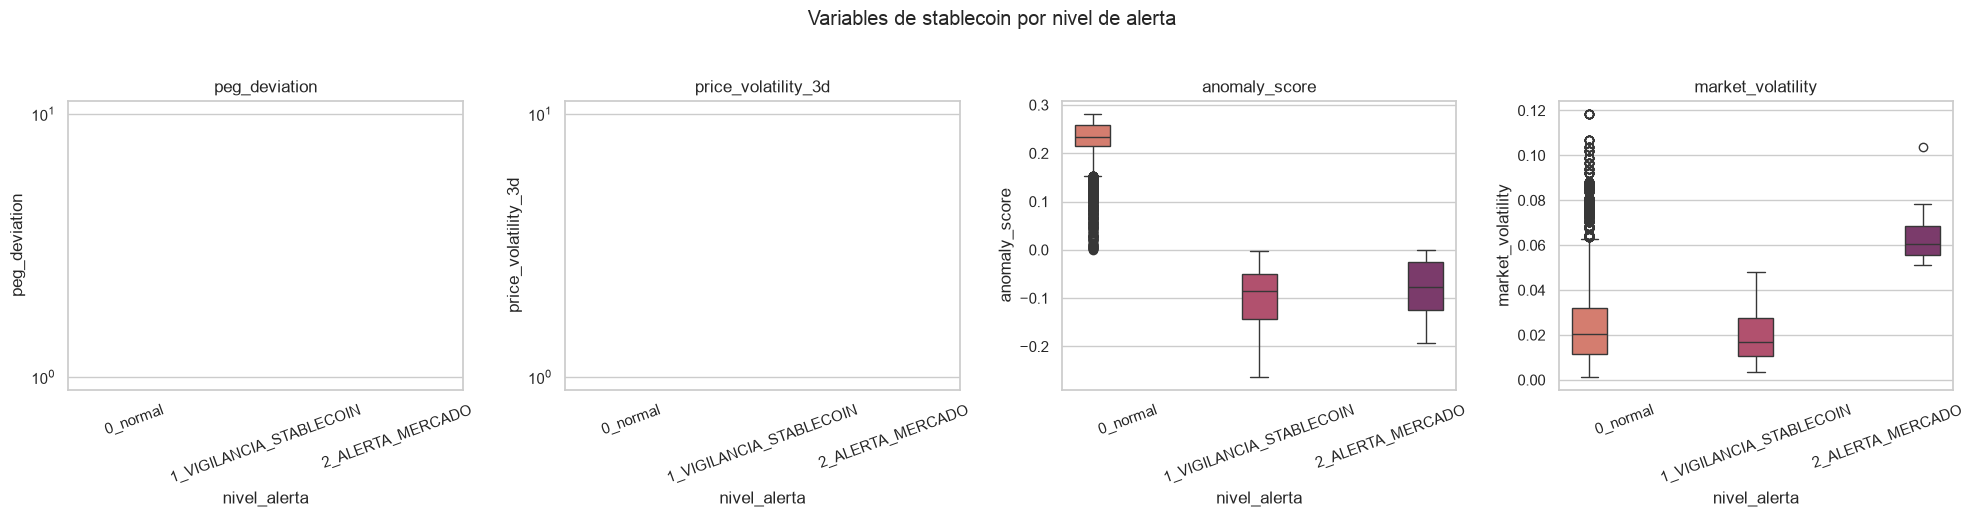

,peg_deviation,price_volatility_3d,anomaly_score,market_volatility
nivel_alerta,,,,
0_normal,0.0,0.0,0.227738,0.025131
1_VIGILANCIA_STABLECOIN,0.0,0.0,-0.100309,0.019460
2_ALERTA_MERCADO,0.0,0.0,-0.077944,0.064918


In [27]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics1 = ["peg_deviation", "price_volatility_3d", "anomaly_score", "market_volatility"]
for ax, m in zip(axes, metrics1):
    sns.boxplot(data=df_merged, x="nivel_alerta", y=m, order=ORDER, hue="nivel_alerta",
                palette="flare", legend=False, ax=ax)
    if m in ("peg_deviation", "price_volatility_3d"):
        ax.set_yscale("log")
    ax.set_title(m)
    ax.tick_params(axis="x", rotation=20)
plt.suptitle("Variables de stablecoin por nivel de alerta", y=1.03)
plt.tight_layout()
plt.show()

df_merged.groupby("nivel_alerta", observed=True)[metrics1].mean()

## 4. Bloque 2 — Nivel de alerta vs. retornos del mercado cripto

Aquí vemos si los niveles de alerta coinciden con caídas (o subidas) fuertes de BTC/ETH/XRP/SOL ese mismo día.
La línea gris en 0 ayuda a ver si la mediana/caja se desplaza hacia territorio negativo (caída) en los niveles
más altos de alerta.

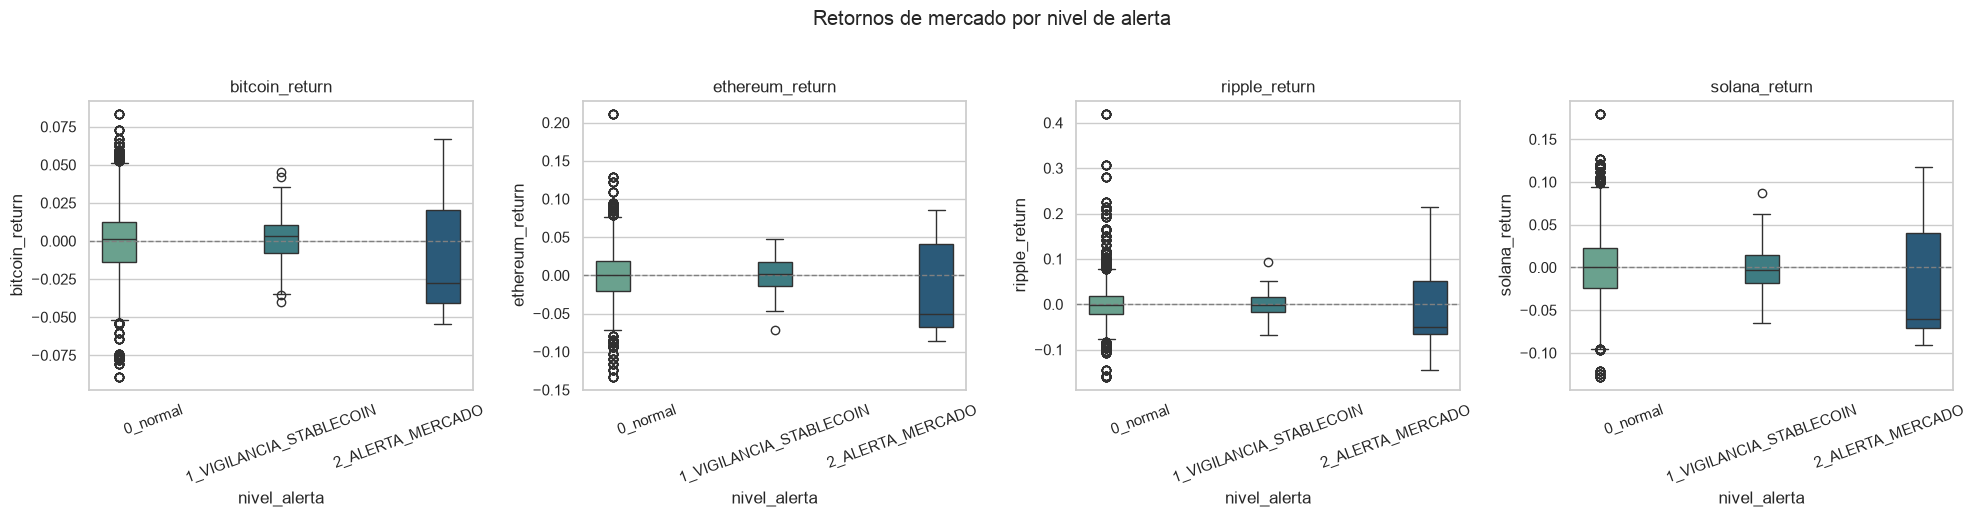

bitcoin_return           ethereum_return            \
                                  mean       std            mean       std   
nivel_alerta                                                                 
0_normal                      0.000248  0.022420       -0.000171  0.033591   
1_VIGILANCIA_STABLECOIN       0.000521  0.017340        0.000071  0.024475   
2_ALERTA_MERCADO             -0.011922  0.039699       -0.020169  0.065064   

                        ripple_return           solana_return            
                                 mean       std          mean       std  
nivel_alerta                                                             
0_normal                     0.001954  0.045473      0.000090  0.039069  
1_VIGILANCIA_STABLECOIN     -0.001602  0.028557     -0.002200  0.030362  
2_ALERTA_MERCADO            -0.000668  0.109655     -0.021353  0.073783

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics2 = ["bitcoin_return", "ethereum_return", "ripple_return", "solana_return"]
for ax, m in zip(axes, metrics2):
    sns.boxplot(data=df_merged, x="nivel_alerta", y=m, order=ORDER, hue="nivel_alerta",
                palette="crest", legend=False, ax=ax)
    ax.axhline(0, color="gray", ls="--", lw=1)
    ax.set_title(m)
    ax.tick_params(axis="x", rotation=20)
plt.suptitle("Retornos de mercado por nivel de alerta", y=1.03)
plt.tight_layout()
plt.show()

df_merged.groupby("nivel_alerta", observed=True)[metrics2].agg(["mean", "std"])

## 5. Bloque 3 — Serie temporal cruzada

Superponemos la desviación media diaria del peg (todas las stablecoins) con el precio de BTC, marcando con
líneas verticales los días de alerta nivel 1 (naranja) y nivel 2 (rojo). Sirve para ver visualmente si las
crisis de peg preceden, coinciden o siguen a movimientos fuertes de BTC.

/var/folders/pq/7bx4chp93qg2ck6vkzg024800000gn/T/ipykernel_16197/394075223.py:9: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax1.set_yscale("log")


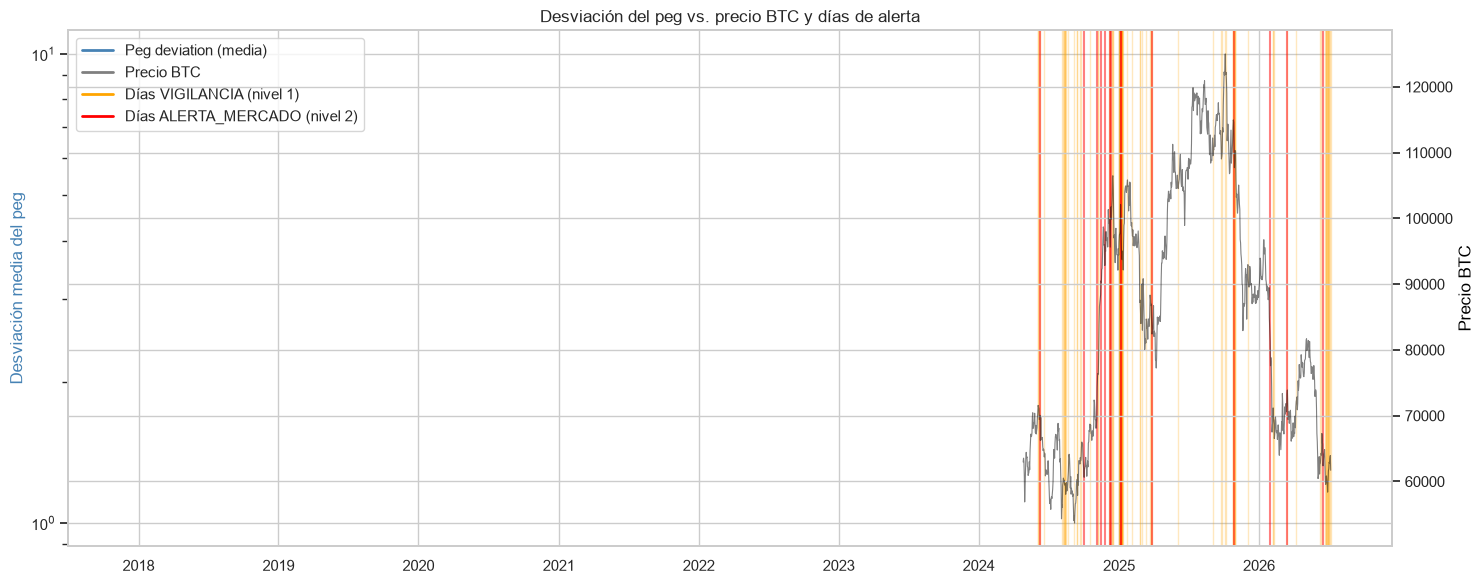

In [29]:
peg_daily = df_stable.groupby("datetime")["peg_deviation"].mean()
btc = df_crypto_pivot["bitcoin"]
alert_days_1 = df_alertas.loc[df_alertas["nivel_alerta"] == "1_VIGILANCIA_STABLECOIN", "datetime"]
alert_days_2 = df_alertas.loc[df_alertas["nivel_alerta"] == "2_ALERTA_MERCADO", "datetime"]

fig, ax1 = plt.subplots(figsize=(15, 6))
ax1.plot(peg_daily.index, peg_daily.values, color="steelblue", lw=1)
ax1.set_ylabel("Desviación media del peg", color="steelblue")
ax1.set_yscale("log")
for d in alert_days_1:
    ax1.axvline(d, color="orange", alpha=0.25, lw=1)
for d in alert_days_2:
    ax1.axvline(d, color="red", alpha=0.5, lw=1.5)

ax2 = ax1.twinx()
ax2.plot(btc.index, btc.values, color="black", lw=0.8, alpha=0.5)
ax2.set_ylabel("Precio BTC", color="black")

custom_lines = [Line2D([0], [0], color="steelblue", lw=2),
                Line2D([0], [0], color="black", lw=2, alpha=0.5),
                Line2D([0], [0], color="orange", lw=2),
                Line2D([0], [0], color="red", lw=2)]
ax1.legend(custom_lines,
           ["Peg deviation (media)", "Precio BTC", "Días VIGILANCIA (nivel 1)", "Días ALERTA_MERCADO (nivel 2)"],
           loc="upper left")
plt.title("Desviación del peg vs. precio BTC y días de alerta")
plt.tight_layout()
plt.show()

## 6. Bloque 4 — Stablecoin vs. nivel de alerta (tabla de contingencia)

Categórica vs. categórica: ¿qué stablecoins concentran más alertas de vigilancia (1) o de mercado (2)?

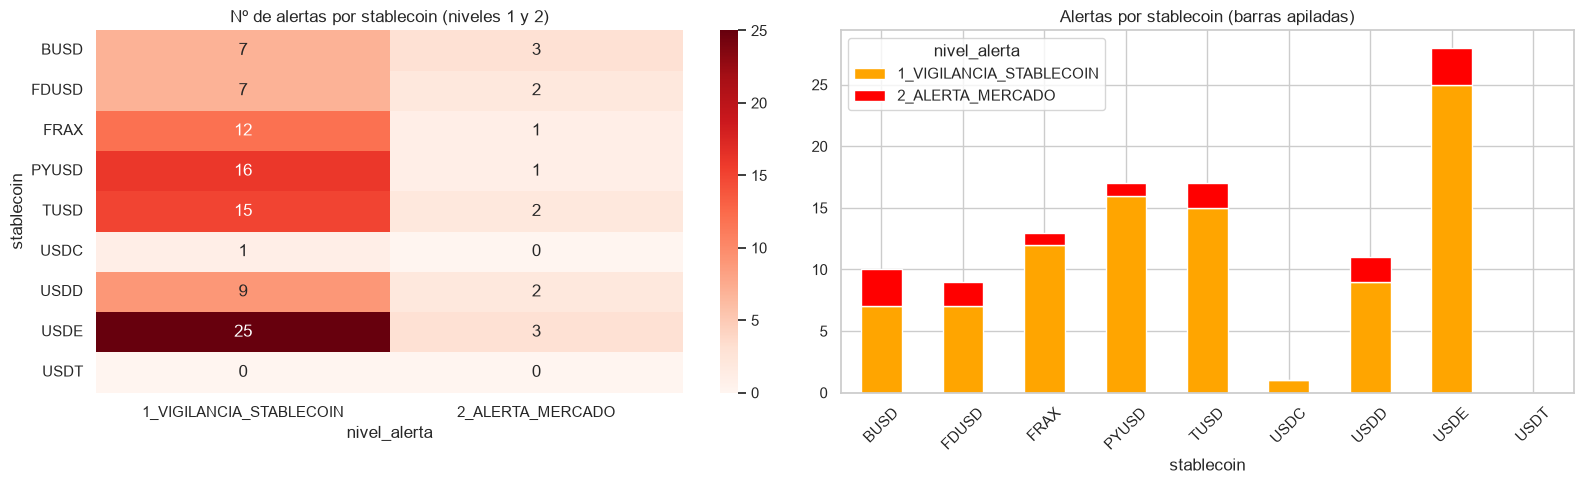

nivel_alerta,0_normal,1_VIGILANCIA_STABLECOIN,2_ALERTA_MERCADO
stablecoin,,,
BUSD,784,7,3
FDUSD,790,7,2
FRAX,786,12,1
PYUSD,782,16,1
TUSD,778,15,2
USDC,798,1,0
USDD,788,9,2
USDE,771,25,3
USDT,799,0,0


In [30]:
ct = pd.crosstab(df_alertas["stablecoin"], df_alertas["nivel_alerta"])
ct_alertas = ct[["1_VIGILANCIA_STABLECOIN", "2_ALERTA_MERCADO"]]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(ct_alertas, annot=True, fmt="d", cmap="Reds", ax=axes[0])
axes[0].set_title("Nº de alertas por stablecoin (niveles 1 y 2)")

ct_alertas.plot(kind="bar", stacked=True, ax=axes[1], color=["orange", "red"])
axes[1].set_title("Alertas por stablecoin (barras apiladas)")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

ct

## 7. Notas

- `alertas_criticas_informe.csv` ya trae, para cada evento de nivel 2, una `narrativa_alerta` en texto
  generada automáticamente — útil para un informe ejecutivo, pero no se usa directamente en el análisis
  numérico de este notebook (son 20 filas, ya cubiertas por el cruce de arriba con más contexto).
- Si quieres profundizar en un evento concreto, filtra `df_criticas` por fecha o por stablecoin y cruza
  con `df_stable`/`df_crypto` en una ventana de +/- unos días alrededor del evento.